In [1]:
import os
import getpass
import requests
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta, timezone

In [2]:
os.environ["GITHUB_TOKEN"] = getpass.getpass(
    "Enter your GitHub token: "
)

TOKEN = os.environ["GITHUB_TOKEN"]

HEADERS = {
    "Accept": "application/vnd.github+json",
    "Authorization": f"Bearer {TOKEN}",
    "X-GitHub-Api-Version": "2026-03-10"
}

OWNER = "google-gemini"
REPO = "gemini-cli"

BASE_URL = "https://api.github.com"

END_DATE = datetime.now(timezone.utc)
START_DATE = END_DATE - timedelta(days=365)

Enter your GitHub token:  ········


In [3]:
def github_search(query):
    url = f"{BASE_URL}/search/issues"

    response = requests.get(
        url,
        headers=HEADERS,
        params={
            "q": query,
            "per_page": 100
        }
    )

    response.raise_for_status()

    return response.json()

In [4]:
issues_query = (
    f"repo:{OWNER}/{REPO} "
    f"is:issue "
    f"created:{START_DATE.date()}..{END_DATE.date()}"
)

issues_data = github_search(issues_query)

issues = issues_data["items"]

print("Issues retrieved:", len(issues))
print("Total matching issues:", issues_data["total_count"])

Issues retrieved: 100
Total matching issues: 9845


In [5]:
months = pd.date_range(
    start=START_DATE.replace(day=1),
    end=END_DATE.replace(day=1),
    freq="MS"
)

In [6]:
def count_activity(activity_type, start_date, end_date):

    if activity_type == "issues":
        activity_filter = "is:issue"

    elif activity_type == "pull_requests":
        activity_filter = "is:pr"

    else:
        raise ValueError(
            "activity_type must be 'issues' or 'pull_requests'"
        )

    query = (
        f"repo:{OWNER}/{REPO} "
        f"{activity_filter} "
        f"created:{start_date}..{end_date}"
    )

    data = github_search(query)

    return data["total_count"]

In [8]:
def count_commits(start_date, end_date):

    url = f"{BASE_URL}/repos/{OWNER}/{REPO}/commits"

    params = {
        "since": start_date.isoformat(),
        "until": end_date.isoformat(),
        "per_page": 1
    }

    response = requests.get(
        url,
        headers=HEADERS,
        params=params
    )

    response.raise_for_status()

    # GitHub doesn't give us total_count here,
    # so we need pagination information.
    #
    # For monthly counts, we'll retrieve the commits
    # for that month.
    commits = []

    page = 1

    while True:

        params["page"] = page
        params["per_page"] = 100

        response = requests.get(
            url,
            headers=HEADERS,
            params=params
        )

        response.raise_for_status()

        data = response.json()

        if not data:
            break

        commits.extend(data)

        if len(data) < 100:
            break

        page += 1

    return len(commits)

In [9]:
monthly_data = []

for month_start in months:
    # Start of the following month
    next_month = month_start + pd.offsets.MonthBegin(1)

    # Convert to dates for the GitHub Search API
    period_start = max(
        START_DATE.date(),
        month_start.date()
    )

    period_end = min(
        END_DATE.date(),
        (next_month - pd.Timedelta(days=1)).date()
    )

    commits = count_commits(period_start, period_end)
    issues = count_activity("issues", period_start, period_end)
    pull_requests = count_activity("pull_requests", period_start, period_end)

    monthly_data.append({
        "month": month_start.strftime("%Y-%m"),
        "commits": commits,
        "issues": issues,
        "pull_requests": pull_requests
    })

monthly_df = pd.DataFrame(monthly_data)

monthly_df

,month,commits,issues,pull_requests
0,2025-09,318,688,539
1,2025-10,513,1128,859
2,2025-11,318,895,605
3,2025-12,273,860,541
4,2026-01,611,1179,993
5,2026-02,580,1175,1374
6,2026-03,655,1708,1822
7,2026-04,349,947,881
8,2026-05,229,661,567
9,2026-06,47,235,337


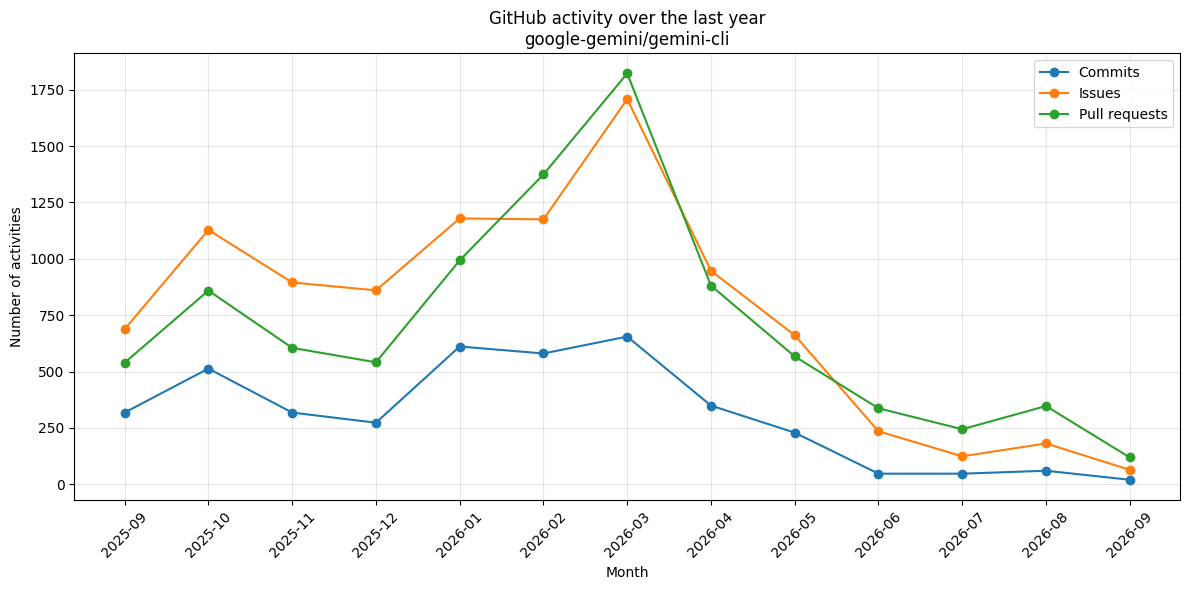

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_df["month"],
    monthly_df["commits"],
    marker="o",
    label="Commits"
)

plt.plot(
    monthly_df["month"],
    monthly_df["issues"],
    marker="o",
    label="Issues"
)

plt.plot(
    monthly_df["month"],
    monthly_df["pull_requests"],
    marker="o",
    label="Pull requests"
)

plt.title(
    "GitHub activity over the last year\n"
    "google-gemini/gemini-cli"
)

plt.xlabel("Month")
plt.ylabel("Number of activities")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [11]:
totals = {
    "Commits": monthly_df["commits"].sum(),
    "Issues": monthly_df["issues"].sum(),
    "Pull requests": monthly_df["pull_requests"].sum()
}

totals_df = pd.DataFrame(
    totals.items(),
    columns=["Activity type", "Count"]
)

totals_df

,Activity type,Count
0,Commits,4020
1,Issues,9845
2,Pull requests,9228


In [13]:
totals_df["Percentage"] = (
    totals_df["Count"]
    / totals_df["Count"].sum()
    * 100
)

totals_df

,Activity type,Count,Percentage
0,Commits,4020,17.407873
1,Issues,9845,42.631966
2,Pull requests,9228,39.960161
